In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('social_media_addiction.csv')
##########################################
def cls_age(i):
    if i < 26.5:
        return 'Plus Jeune'
    else:
        return 'Adulte'
#########################################
def intrct (i):
    if i >= 245.25 and i <= 325:
        return 'Très Haute'
    elif i >= 165.50 and i <= 245.25:
        return 'Haute'
    elif i >= 85.75 and i <= 165.50:
        return 'Normal'
    elif i >= 6 and i <= 85.75:
        return 'Baisse'
##########################################
def usage_niveau (i):
    if i >= 230 and i <= 300:
        return 'Très Haute'
    elif i >= 160 and i <= 230:
        return 'Haute'
    elif i >= 90 and i <= 160:
        return 'Normal'
    elif i >= 20 and i <= 90:
        return 'Baisse'
##########################################
def snt_mnt(i):
    if i >= 73.75 and i <= 90 :
        return 'Bonne santé'
    elif i >= 57.50 and i <= 73.75 :
        return 'Santé stable'
    elif i >= 41.25 and i <= 57.50:
        return 'Santé en attention'
    elif i >= 25 and i <= 41.25 :
        return 'Mauvaise Santé'
##########################################
df['Classe_age'] = df['Age'].apply(cls_age)
df['Interactions'] = df['Posts_Per_Day'] + df['Likes_Received_Daily'] + df['Comments_Received_Daily'] + df['Messages_Sent_Daily']
df['Niveau_interaction'] = df['Interactions'].apply(intrct)
df['Niveau_usage'] = df['Daily_Usage_Time_min'].apply(usage_niveau)
df['Niveau_Santé'] = df['Mental_Health_Index'].apply(snt_mnt)

In [3]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time_min',
       'Posts_Per_Day', 'Likes_Received_Daily', 'Comments_Received_Daily',
       'Messages_Sent_Daily', 'Scroll_Rate_ppm', 'Addiction_Level',
       'Emotional_State_Post_Usage', 'Productivity_Loss_Score',
       'Mental_Health_Index', 'FOMO_Score', 'Classe_age', 'Interactions',
       'Niveau_interaction', 'Niveau_usage', 'Niveau_Santé'],
      dtype='object')

In [4]:
group = (
    df
    .groupby(['Niveau_usage','Niveau_Santé'])
    .size()
    .sort_values(ascending = False)
)
group
c = []
nu = df['Niveau_usage'].unique()
for i in nu:
    b = group[i]
    c.append(b)

df_snt = pd.DataFrame(c)
df_snt.index = nu.tolist()
df_snt = df_snt.fillna(0)
df_snt.T

,Normal,Haute,Baisse,Très Haute
Niveau_Santé,,,,
Santé stable,4.0,0.0,1.0,0.0
Santé en attention,2.0,2.0,0.0,0.0
Mauvaise Santé,0.0,4.0,0.0,2.0
Bonne santé,0.0,0.0,5.0,0.0


In [5]:
df_snt.index

Index(['Normal', 'Haute', 'Baisse', 'Très Haute'], dtype='object')

In [6]:
nu

array(['Normal', 'Haute', 'Baisse', 'Très Haute'], dtype=object)

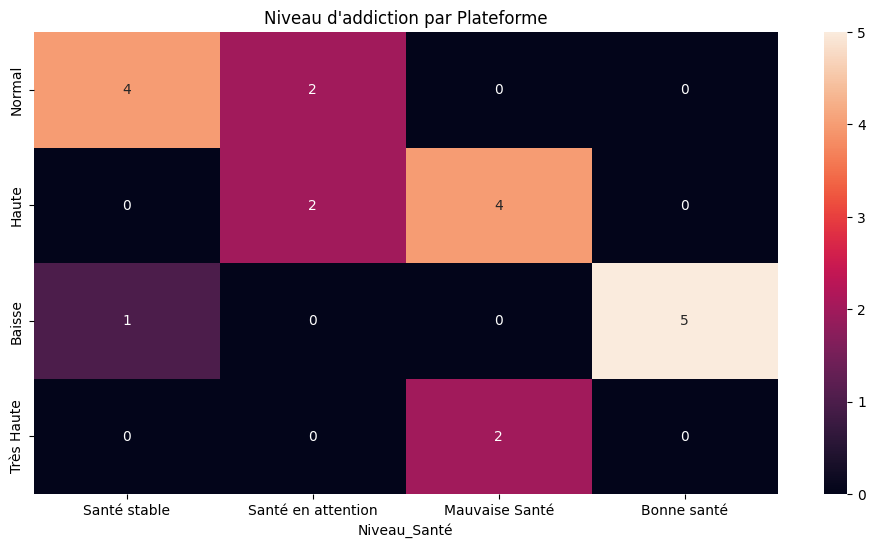

In [7]:
plt.figure(figsize=(12,6))
sns.heatmap(df_snt, annot=True, fmt=".0f")
plt.title("Niveau d'addiction par Plateforme")
plt.show()